# DEPARTMENT OF COMPUTER SCIENCE AND ENGINEERING (AI)

# DEEP LEARNING LAB RECORD

---

# LAB - 03

## Student Details

**Name:** P. Harshith

**Register Number:** CH.SC.U4AIE24057

**Course Name:** Deep Learning

**Course Code:** 22AIE304

---

# Experiment Title

**Advanced Hyperparameter Optimization for a Multilayer Perceptron using Grid Search**

---

## Aim

To optimize the performance of a Multilayer Perceptron (MLP) classifier by tuning its hyperparameters using GridSearchCV.

---

## Objective

- Implement an MLP classifier.
- Perform hyperparameter tuning using GridSearchCV.
- Identify the optimal activation function, hidden layer size, and learning rate.
- Evaluate the optimized model.

---

## Dataset

**Dataset Name:** Iris Dataset

**Number of Samples:** 150

**Number of Features:** 4

**Target Classes:**
- Iris Setosa
- Iris Versicolor
- Iris Virginica

---

## Software Requirements

- Python 3.x
- NumPy
- Pandas
- Scikit-Learn
- Matplotlib
- Jupyter Notebook

---

## Required Libraries

- numpy
- pandas
- matplotlib
- sklearn

In [31]:
!pip install numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [33]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True)

dataset = iris.frame

dataset.columns = [
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth",
    "Species"
]

dataset.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [34]:
X = dataset.iloc[:, :-1].values

y = dataset.iloc[:, -1].values

encoder = LabelEncoder()

y = encoder.fit_transform(y)

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
parameter_grid = {

    "hidden_layer_sizes":[(8,), (16,), (16,8)],

    "activation":["relu","tanh","logistic"],

    "learning_rate_init":[0.001,0.01,0.1],

    "max_iter":[500]

}

In [37]:
grid = GridSearchCV(

    estimator=MLPClassifier(random_state=42),

    param_grid=parameter_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train, y_train)

,estimator,MLPClassifier(random_state=42)
,param_grid,"{'activation': ['relu', 'tanh', ...], 'hidden_layer_sizes': [(8,), (16,), ...], 'learning_rate_init': [0.001, 0.01, ...], 'max_iter': [500]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(16,)"


In [38]:
print("Best Parameters")

print(grid.best_params_)

print()

print("Best Accuracy")

print(grid.best_score_)

Best Parameters
{'activation': 'tanh', 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.01, 'max_iter': 500}

Best Accuracy
0.9666666666666668


In [39]:
best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

In [40]:
accuracy = accuracy_score(y_test, predictions)

print("Test Accuracy :", accuracy)

Test Accuracy : 0.9666666666666667


In [41]:
print(confusion_matrix(y_test, predictions))

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [42]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [43]:
results = pd.DataFrame(grid.cv_results_)

results[
    [
        "param_hidden_layer_sizes",
        "param_activation",
        "param_learning_rate_init",
        "mean_test_score"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

,param_hidden_layer_sizes,param_activation,param_learning_rate_init,mean_test_score
22,"(16,)",logistic,0.010,0.966667
15,"(16, 8)",tanh,0.001,0.966667
13,"(16,)",tanh,0.010,0.966667
19,"(8,)",logistic,0.010,0.966667
5,"(16,)",relu,0.100,0.966667
16,"(16, 8)",tanh,0.010,0.958333
14,"(16,)",tanh,0.100,0.958333
10,"(8,)",tanh,0.010,0.958333
12,"(16,)",tanh,0.001,0.958333
6,"(16, 8)",relu,0.001,0.958333


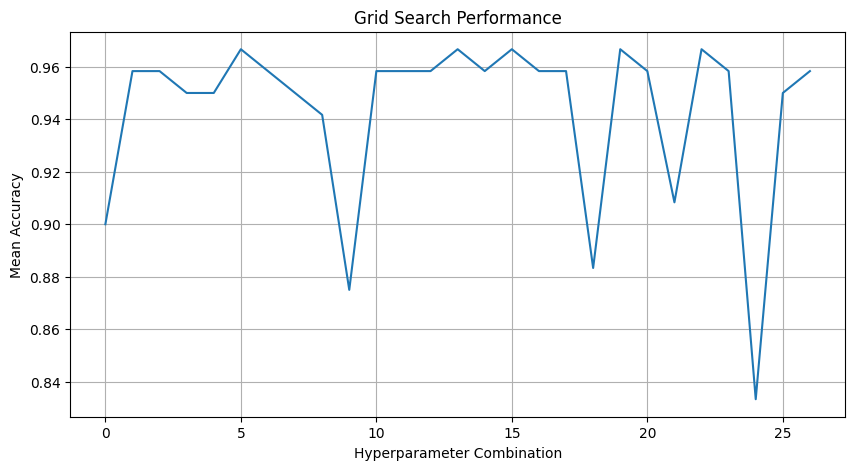

In [44]:
plt.figure(figsize=(10,5))

plt.plot(results["mean_test_score"])

plt.xlabel("Hyperparameter Combination")

plt.ylabel("Mean Accuracy")

plt.title("Grid Search Performance")

plt.grid(True)

plt.show()

In [45]:
results = pd.DataFrame(grid.cv_results_)

results = results[
    [
        "param_hidden_layer_sizes",
        "param_activation",
        "param_learning_rate_init",
        "mean_test_score",
        "rank_test_score"
    ]
]

results.sort_values("rank_test_score").head(5)

,param_hidden_layer_sizes,param_activation,param_learning_rate_init,mean_test_score,rank_test_score
13,"(16,)",tanh,0.010,0.966667,1
15,"(16, 8)",tanh,0.001,0.966667,1
22,"(16,)",logistic,0.010,0.966667,1
19,"(8,)",logistic,0.010,0.966667,1
5,"(16,)",relu,0.100,0.966667,5
